In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

from scipy.stats import ttest_ind, mannwhitneyu

from src.config import DADOS_ORIGINAIS, DADOS_LIMPOS
from src.graficos import PALETTE

sns.set_theme(style='whitegrid', palette='bright')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv(DADOS_ORIGINAIS)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
df.describe(exclude='number')

,diagnosis
count,569
unique,2
top,B
freq,357


In [7]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
df['diagnosis'].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

Primeiras observações:
- Coluna alvo `diagnosis:`
    - Transformar a coluna em Booleana (0 ou 1).
    - Balancear a coluna para ter a mesma quantidade de cada tipo de diagnóstico.
 - Ajustar as features para ficarem com a mesma escala antes de incluí-lás no modelo de Classificação. (Pré-processamento)

In [9]:
df[df.duplicated()]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


In [10]:
df[df.duplicated("id")]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


In [11]:
#remover coluna "id"
df = df.drop(columns=['id'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [12]:
#colocando as colunas em ordem alfabética
df =df.reindex(sorted(df.columns), axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area_mean                569 non-null    float64
 1   area_se                  569 non-null    float64
 2   area_worst               569 non-null    float64
 3   compactness_mean         569 non-null    float64
 4   compactness_se           569 non-null    float64
 5   compactness_worst        569 non-null    float64
 6   concave points_mean      569 non-null    float64
 7   concave points_se        569 non-null    float64
 8   concave points_worst     569 non-null    float64
 9   concavity_mean           569 non-null    float64
 10  concavity_se             569 non-null    float64
 11  concavity_worst          569 non-null    float64
 12  diagnosis                569 non-null    str    
 13  fractal_dimension_mean   569 non-null    float64
 14  fractal_dimension_se     569 non-null

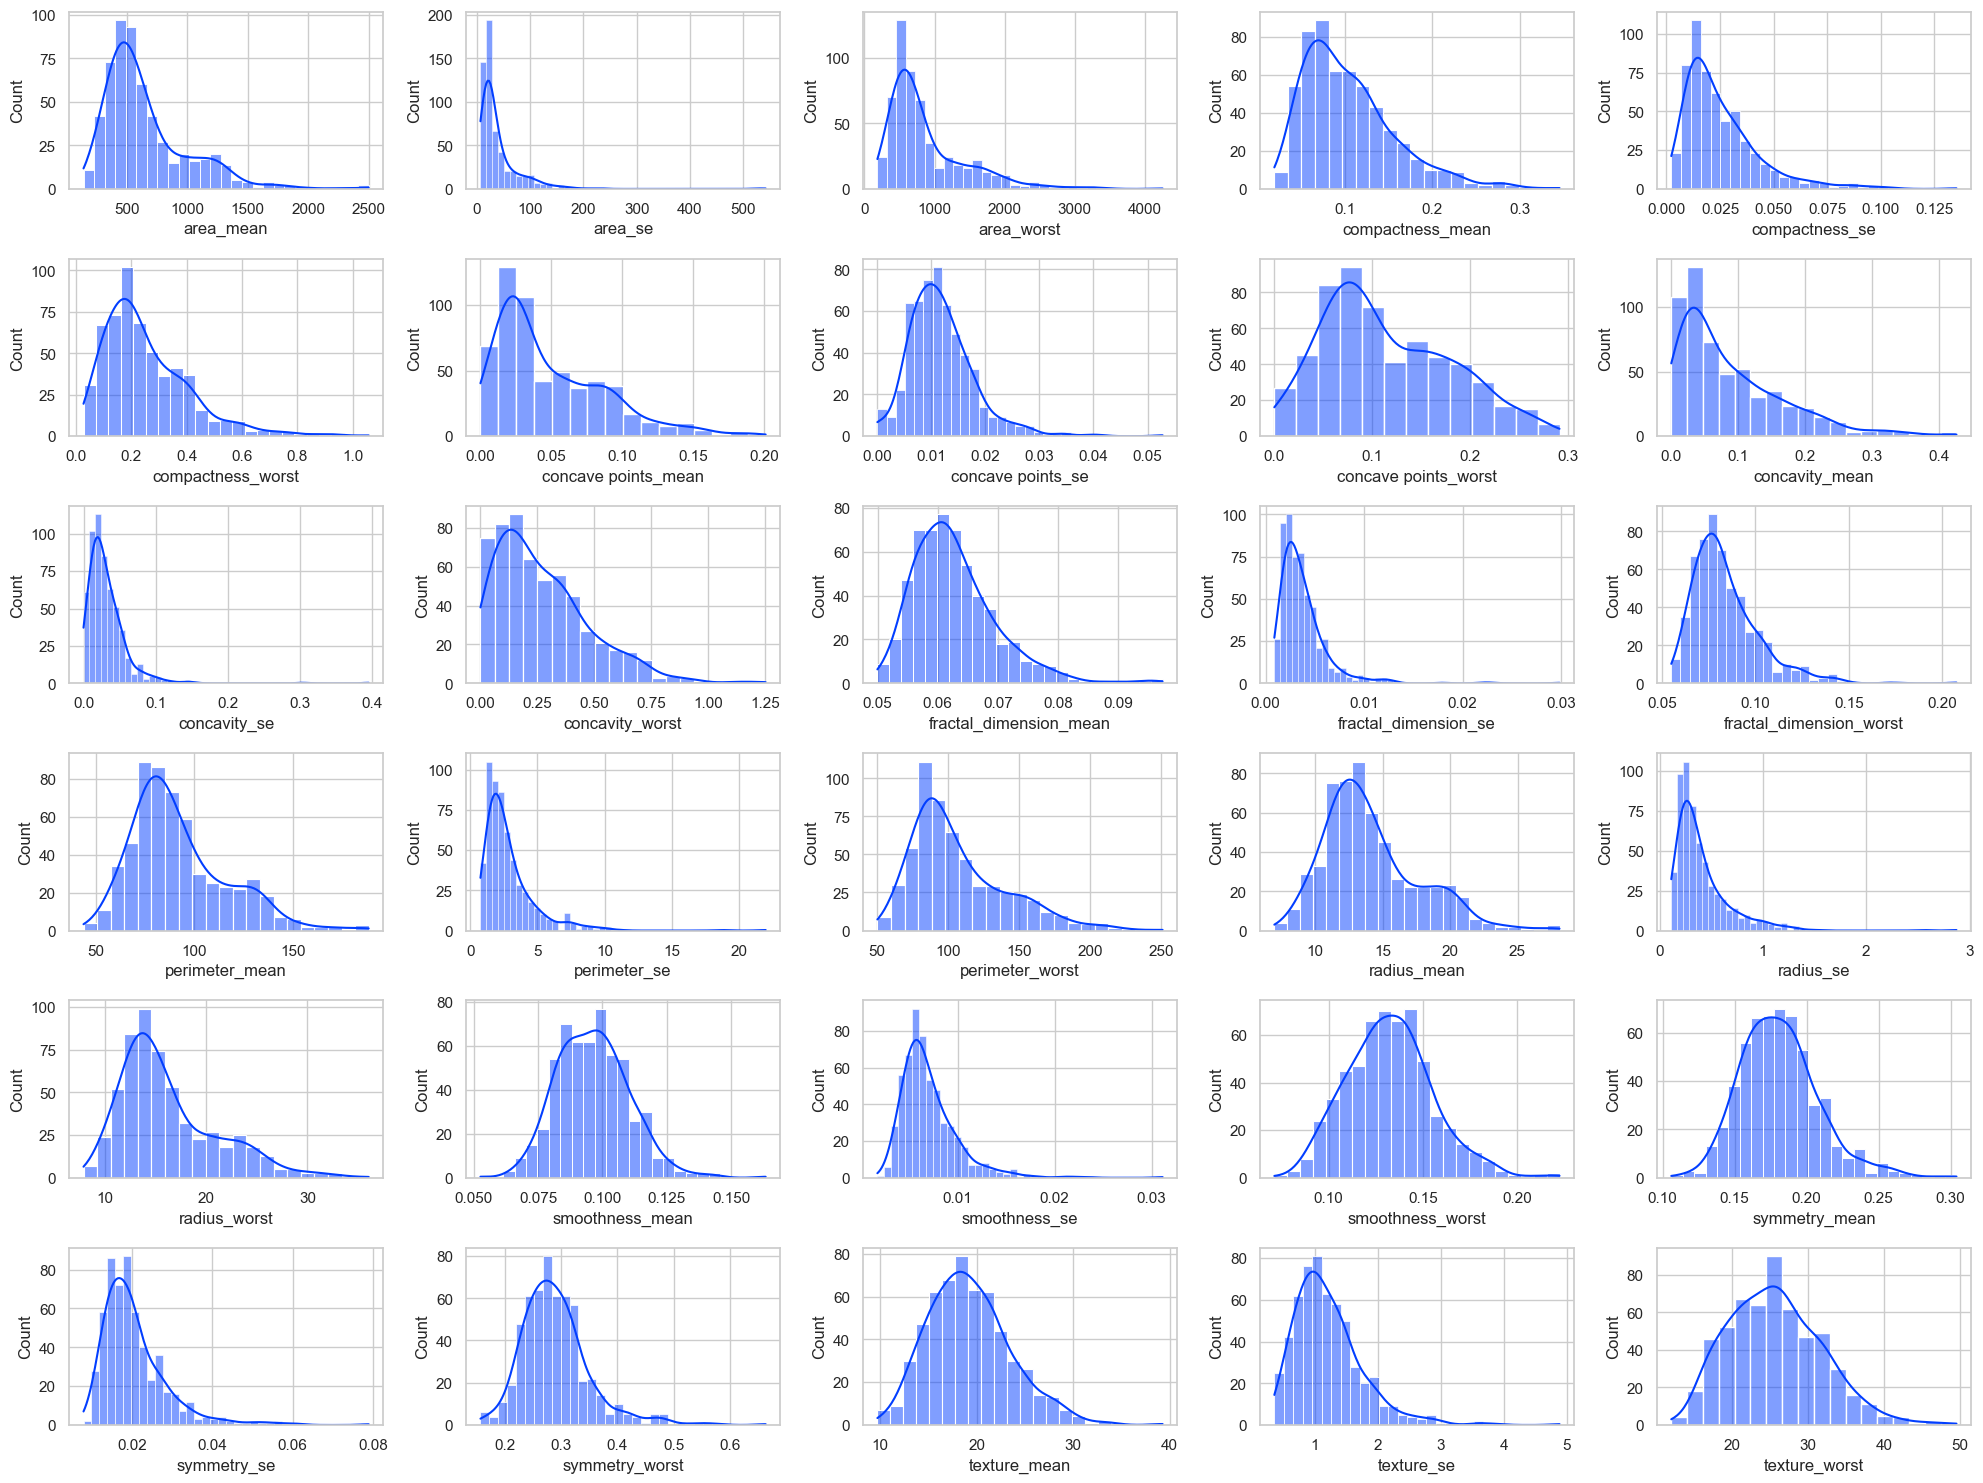

In [13]:
#Análise das distribuições das variáveis numéricas
fig, axs = plt.subplots(6, 5, figsize=(20, 15))
for i, column in enumerate(df.select_dtypes(include=np.number).columns):
    sns.histplot(data=df, x=column, ax=axs[i//5, i%5], kde=True)
plt.tight_layout()
plt.show()

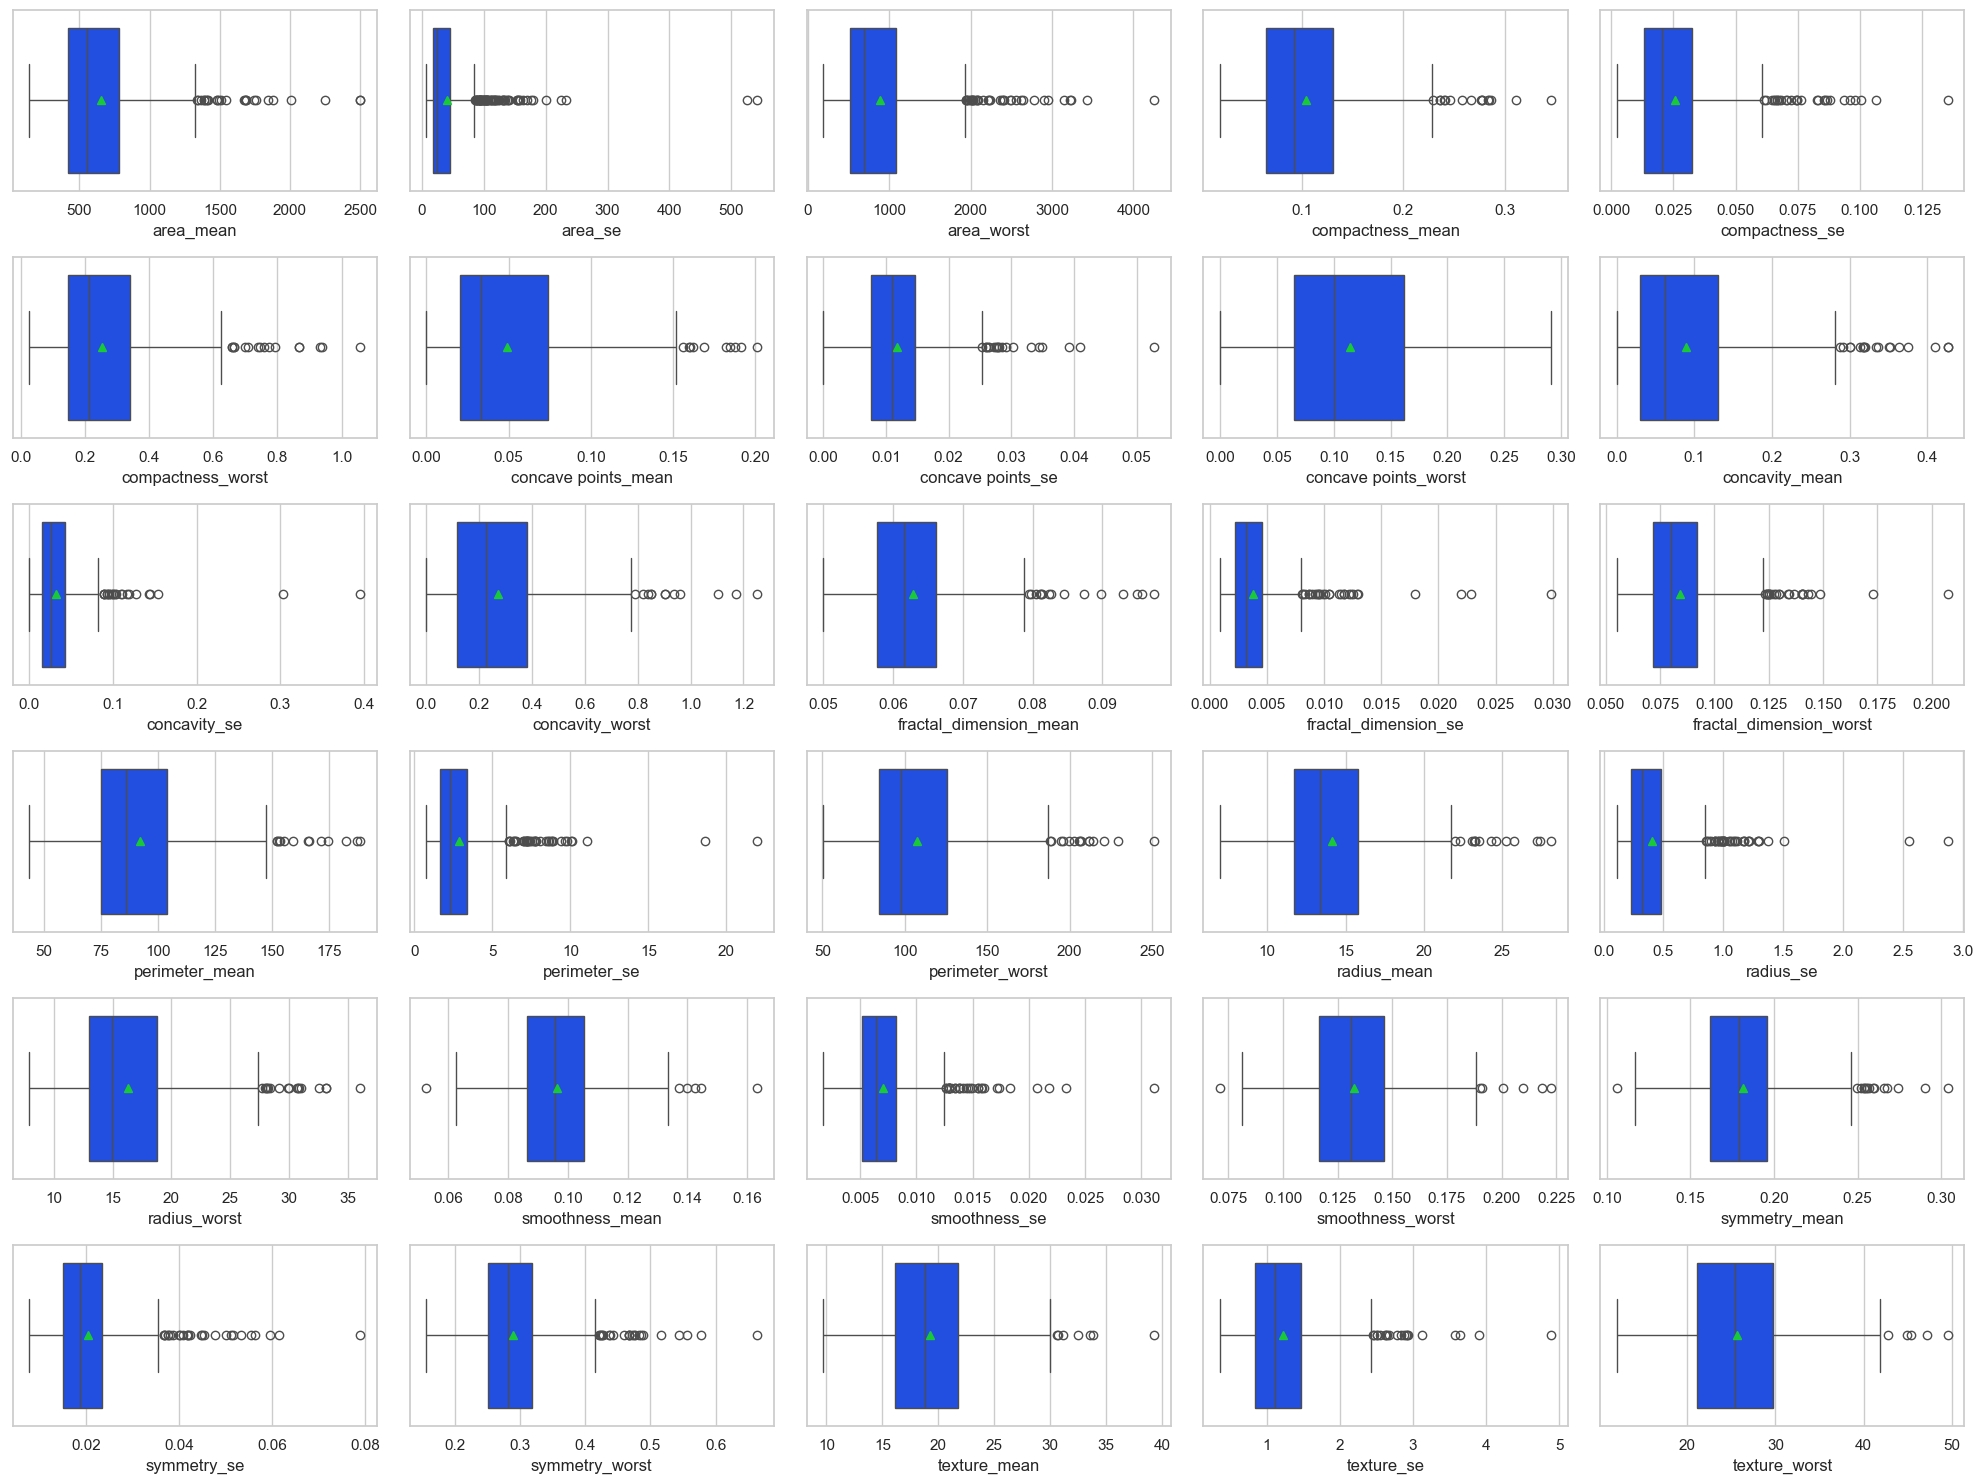

In [14]:
#Análise das distribuições das variáveis numéricas
fig, axs = plt.subplots(6, 5, figsize=(20, 15))
for i, column in enumerate(df.select_dtypes(include=np.number).columns):
    sns.boxplot(data=df, x=column, showmeans=True, ax=axs[i//5, i%5])
plt.tight_layout()
plt.show()

Análise das distribuições:
- Todas as features, exeto `concave points_worst`, tem outliers a direita.
- As features tem assimetrias com uma cauda alongada para a direita.

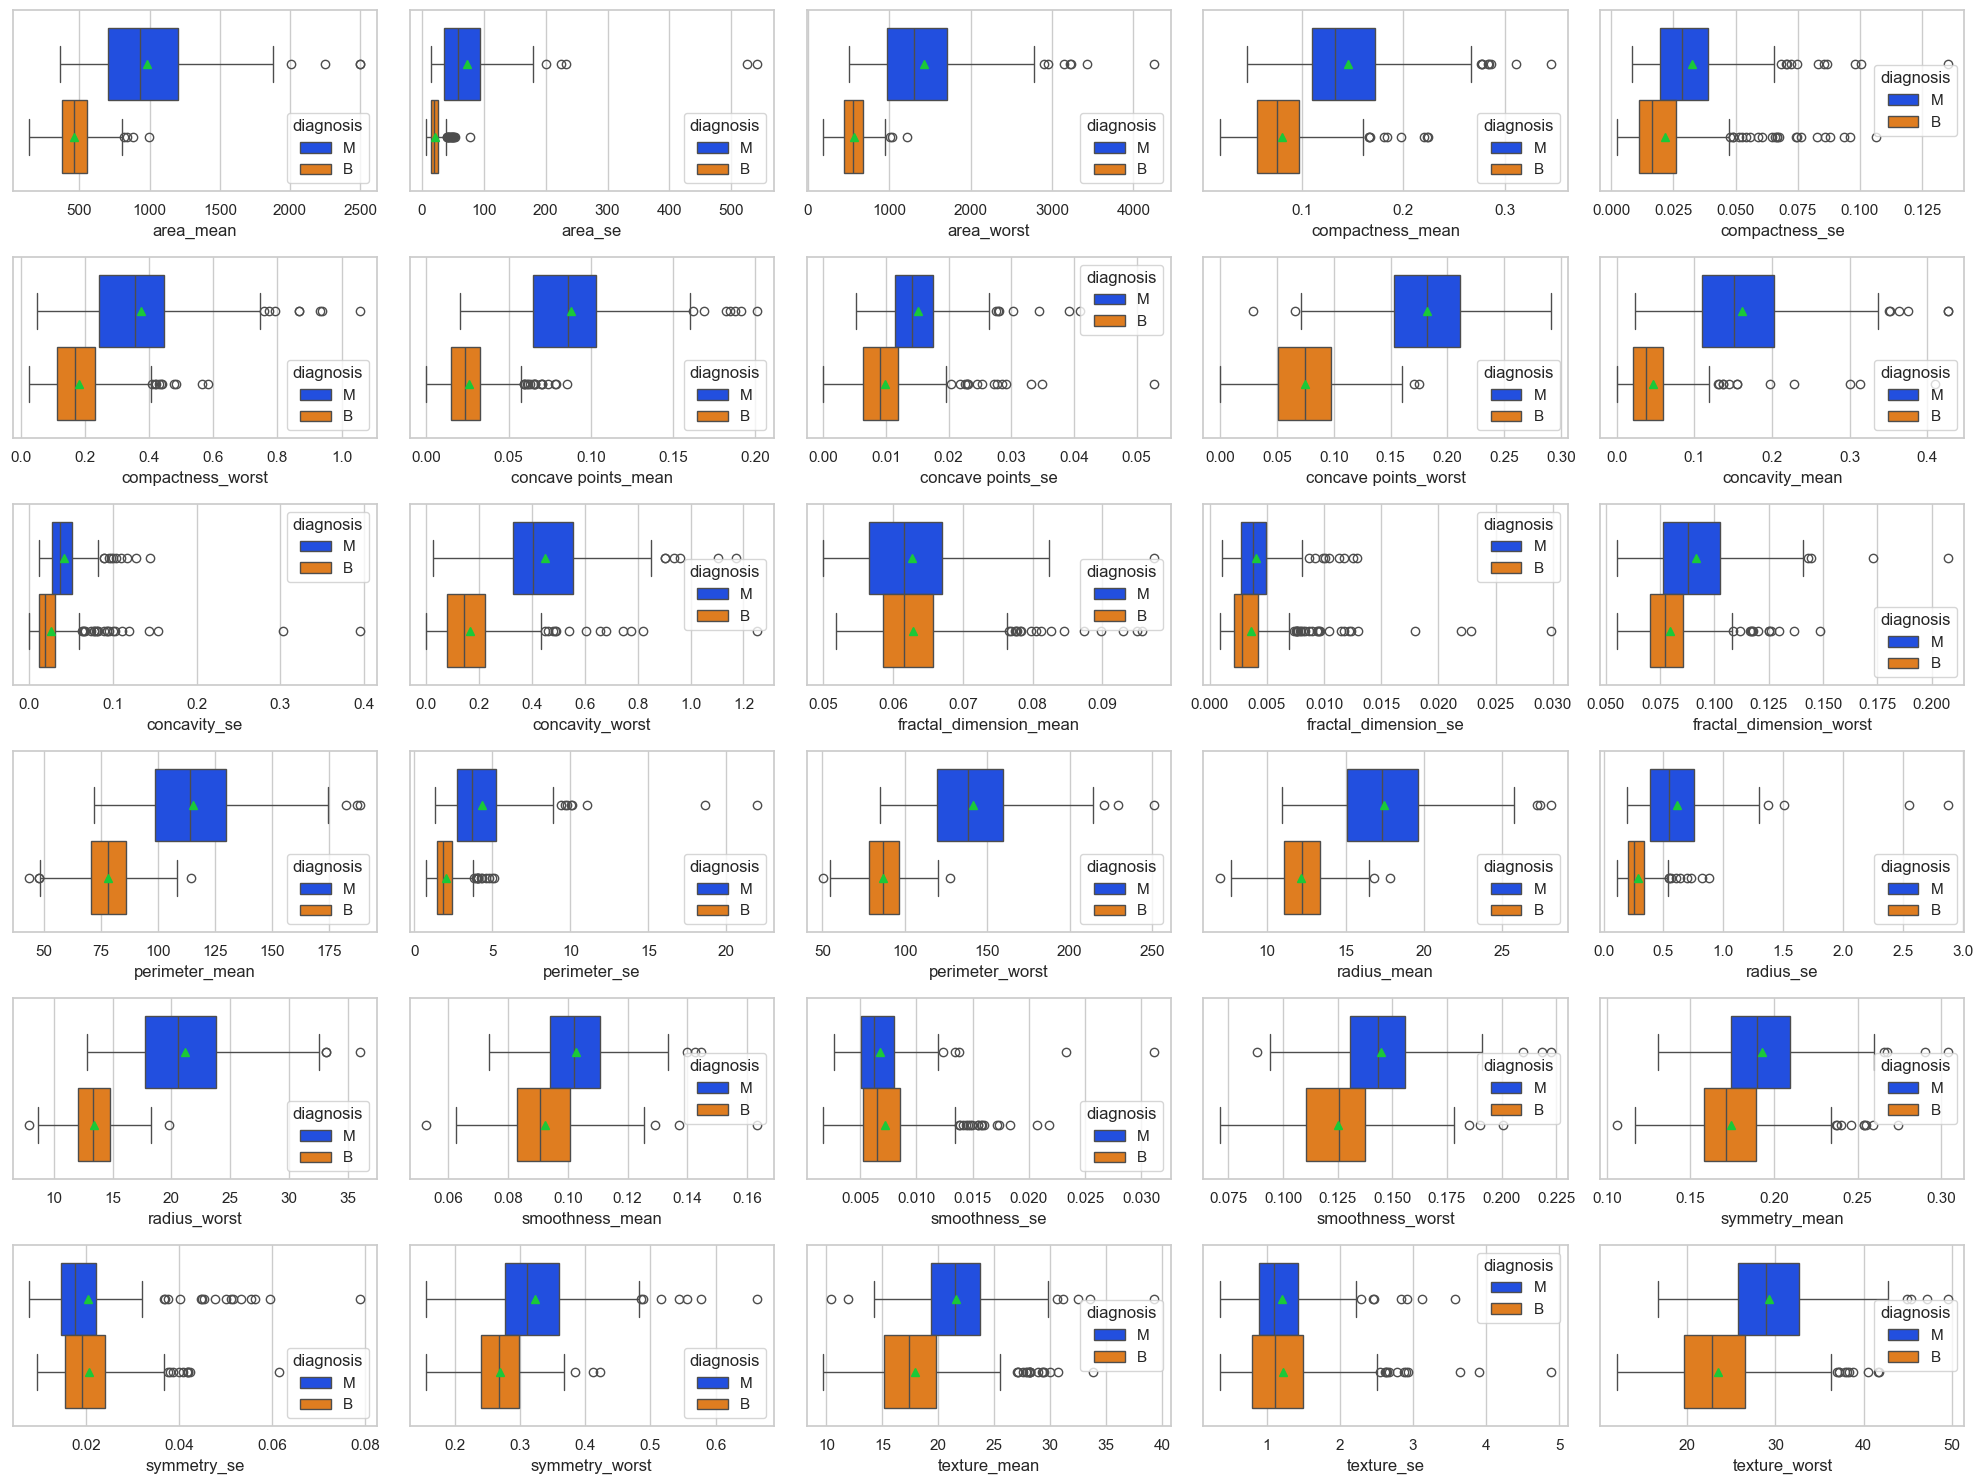

In [15]:
#Análise das distribuições das variáveis numéricas
fig, axs = plt.subplots(6, 5, figsize=(20, 15))
for i, column in enumerate(df.select_dtypes(include=np.number).columns):
    sns.boxplot(data=df, x=column, showmeans=True, hue='diagnosis', ax=axs[i//5, i%5])
plt.tight_layout()
plt.show()

Temos algumas classes que parecem não apresentar diferença quanto ao diagnósticos.
Iremos fazer outras análises para confirmar isso, mas podemos já deixar a notado para conferir depois.
Essa informação é importante para definir a seleção de features que irão para o modelo.

- concavity_se
- fractal_dimension_mean
- fractal_dimension_se
- smoothness_se
- symmetry_se
- texture_se


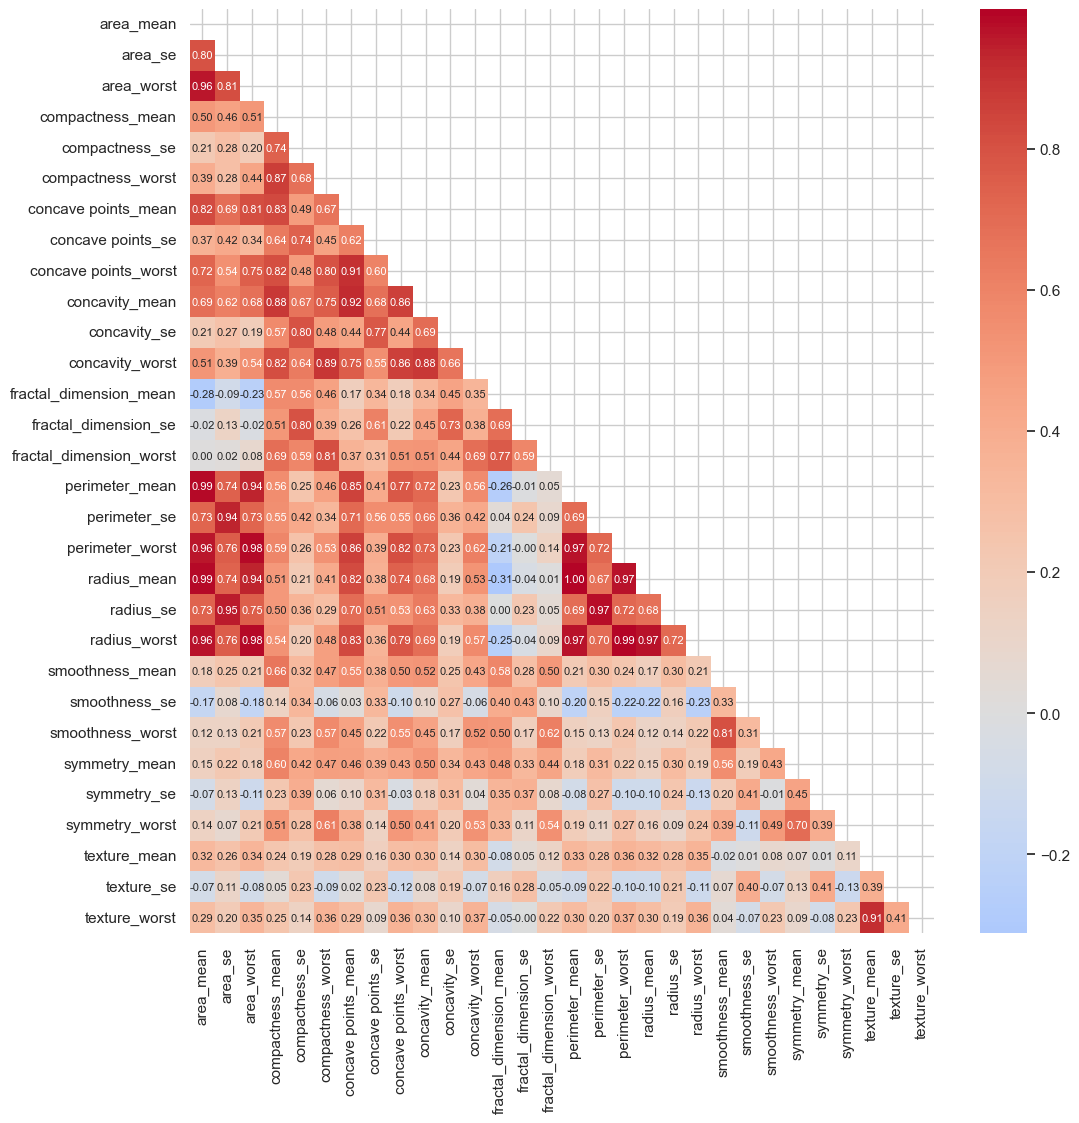

In [16]:
#grafico de correlação
matriz = np.triu(df.select_dtypes("number").corr())

fig, ax = plt.subplots(figsize=(12, 12))
 
sns.heatmap(
    df.select_dtypes("number").corr(), 
    mask = matriz,
    annot=True, 
    fmt=".2f",
    ax=ax,
    cmap=PALETTE, 
    center=0,
    annot_kws={"size": 8},)

plt.show()

### Testes de hipóteses

In [17]:
colunas_numericas = df.select_dtypes("number").columns.to_list()

analise_colunas_ttest = {}
analise_colunas_mw = {}

coluna_target = 'diagnosis'

In [18]:
classes = df[coluna_target].unique()
classes

<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

In [19]:
alfa = 0.05

In [20]:
agrupamento = df.groupby(coluna_target)
agrupamento

In [21]:
for coluna in colunas_numericas:
    grupo1 = agrupamento.get_group(classes[0])[coluna]
    grupo2 = agrupamento.get_group(classes[1])[coluna]
    
    # Teste t de Student
    t_stat, p_value_ttest = ttest_ind(grupo1, grupo2)
    analise_colunas_ttest[coluna] = (t_stat, p_value_ttest, p_value_ttest < alfa)
    
    # Teste de Mann-Whitney U
    u_stat, p_value_mw = mannwhitneyu(grupo1, grupo2)
    analise_colunas_mw[coluna] = (u_stat, p_value_mw, p_value_mw < alfa)

In [22]:
df_ttest = pd.DataFrame(analise_colunas_ttest, index=['t_stat', 'p_value', 'significativo']).T.sort_values('p_value')
df_ttest


,t_stat,p_value,significativo
concave points_worst,31.054555,0.0,True
perimeter_worst,29.965717,0.0,True
concave points_mean,29.354319,0.0,True
radius_worst,29.339082,0.0,True
perimeter_mean,26.405213,0.0,True
area_worst,25.72159,0.0,True
radius_mean,25.435822,0.0,True
area_mean,23.938687,0.0,True
concavity_mean,23.103963,0.0,True
concavity_worst,20.897175,0.0,True


In [23]:
df_ttest[df_ttest['significativo']==False]


,t_stat,p_value,significativo
fractal_dimension_se,1.86233,0.063074,False
smoothness_se,-1.599365,0.110297,False
fractal_dimension_mean,-0.305711,0.759937,False
texture_se,-0.197724,0.843332,False
symmetry_se,-0.155298,0.876642,False


In [24]:
df_mw = pd.DataFrame(analise_colunas_mw, index=['u_stat', 'p_value', 'significativo']).T.sort_values('p_value')
df_mw

,u_stat,p_value,significativo
perimeter_worst,73826.0,0.0,True
radius_worst,73447.0,0.0,True
area_worst,73400.5,0.0,True
concave points_worst,73164.0,0.0,True
concave points_mean,72992.5,0.0,True
perimeter_mean,71665.0,0.0,True
area_mean,71015.5,0.0,True
concavity_mean,70978.5,0.0,True
radius_mean,70955.0,0.0,True
area_se,70114.5,0.0,True


In [25]:
df_mw[df_mw['significativo']==False]

,u_stat,p_value,significativo
smoothness_se,35483.5,0.213632,False
fractal_dimension_mean,36671.5,0.537186,False
texture_se,38719.5,0.643693,False


Conforme os testes estatísticos relizados acima, temos as seguintes colunas que não há diferença entre os tipos de diagnótico.

In [26]:
df_ttest[df_ttest['significativo']==False].index.to_list()


['fractal_dimension_se',
 'smoothness_se',
 'fractal_dimension_mean',
 'texture_se',
 'symmetry_se']

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area_mean                569 non-null    float64
 1   area_se                  569 non-null    float64
 2   area_worst               569 non-null    float64
 3   compactness_mean         569 non-null    float64
 4   compactness_se           569 non-null    float64
 5   compactness_worst        569 non-null    float64
 6   concave points_mean      569 non-null    float64
 7   concave points_se        569 non-null    float64
 8   concave points_worst     569 non-null    float64
 9   concavity_mean           569 non-null    float64
 10  concavity_se             569 non-null    float64
 11  concavity_worst          569 non-null    float64
 12  diagnosis                569 non-null    str    
 13  fractal_dimension_mean   569 non-null    float64
 14  fractal_dimension_se     569 non-null

In [28]:
df.to_parquet(DADOS_LIMPOS, index=False)